In [2]:
# -----------------------
# libraries and reloading flowsheets
# -----------------------

import importlib
import biosteam as bst

import sabre.chemicals as chem
import sabre.units.ad as ad_unit
import sabre.units.biogas_upgrading as up_unit
import sabre.units.screwpress as sp_unit
import sabre.systems.ad_biogas_system as sysmod
import sabre.units.press, sabre.units.mill
import sabre.tea as tea 

# reload modules
importlib.reload(chem)
importlib.reload(ad_unit)
importlib.reload(up_unit)
importlib.reload(sp_unit)
importlib.reload(sp_unit)
importlib.reload(sysmod)
importlib.reload(sabre.units.press)
importlib.reload(sabre.units.mill)
importlib.reload(tea)

# reset flowsheet
bst.main_flowsheet.clear()

/opt/anaconda3/envs/sabre/lib/python3.10/site-packages/biosteam/_unit.py:1083: RuntimeWarning: the purchase cost item, 'Membrane upgrading skid', has no defined bare-module factor in the 'BiogasUpgrading.F_BM' dictionary; bare-module factor now has a default value of 1
  warn(f"the purchase cost item, '{name}', has "


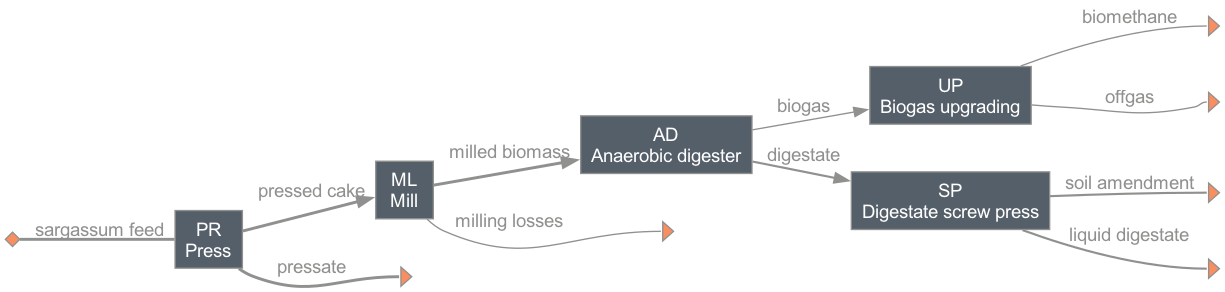

None

System: AD_Biogas_sys
ins...
[0] sargassum_feed  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      3.01e+04
                    Cellulose  335
                    Ash        2.86e+04
outs...
[0] milling_losses  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      1.26e+03
                    Cellulose  49.2
                    Ash        4.21e+03
[1] soil_amendment  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      1.03e+03
                    Cellulose  55.8
                    Ash        9.54e+03
[2] liquid_digestate  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      5.95e+03
                    Cellulose  83.7
                    Ash        1.43e+04
[3] biomethane  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Methane        414
                    CarbonDioxide  20.9
[4] offgas  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Methane        4.19
             

In [84]:
# -----------------------
# # Building the system
# -----------------------

# set thermo
chem.create_chemicals()

# build + simulate
sys = sysmod.create_ad_biogas_system(quality="pelagic_high_quality")
sys.simulate(design_and_cost=True)

# generate diagram
from IPython.display import display
display(sys.diagram(format="png"))

# flowsheet summary
sys.show()

print("System:", sys.ID)
print("Units:", [u.ID for u in sys.units])
print("Streams:", [s.ID for s in sys.streams])

F = bst.main_flowsheet.stream
U = bst.main_flowsheet.unit

In [1]:
# -----------------------
# Stream and Unit checks
# -----------------------
def get_stream(name):
    return getattr(F, name, None)

def safe_imass(stream, IDs):
    if stream is None: return None
    return sum(float(stream.imass[i]) for i in IDs if i in stream.chemicals.IDs)

def safe_imol(stream, ID):
    if stream is None: return None
    return float(stream.imol[ID]) if ID in stream.chemicals.IDs else 0.0

def ratio(num, den):
    if den is None or den == 0: return None
    return float(num) / float(den)

def fmt(x, nd=4):
    if x is None: return None
    try: return round(float(x), nd)
    except: return x

def print_section(title):
    print("\n" + "=" * 10, title, "=" * 10)

def print_unit_costs(unit, label):
    print(f"{label} design_results:", getattr(unit, "design_results", {}))
    print(f"{label} baseline_purchase_costs:", getattr(unit, "baseline_purchase_costs", {}))
    pu = getattr(unit, "power_utility", None)
    if pu is not None:
        print(f"{label} power (kW):", fmt(getattr(pu, "consumption", 0.0)))


# -----------------------
# STREAMS
# -----------------------
TS_ids = ["Cellulose", "Ash"]

# preprocessing streams
feed     = get_stream("sargassum_feed")
cake     = get_stream("pressed_cake")
pressate = get_stream("pressate")
milled   = get_stream("milled_biomass")
losses   = get_stream("milling_losses")

# upgrading outlets
biogas = get_stream("biogas")
bm     = get_stream("biomethane")
off    = get_stream("offgas")

# digestate separation outlets
soil_named = get_stream("soil_amendment")
liq_named  = get_stream("liquid_digestate")


# -----------------------
# MASS CLOSURE CHECK
# -----------------------
print_section("MASS CLOSURE CHECKS")

if feed is None:
    print("Feed mass (kg/hr): <stream 'sargassum_feed' not found>")
else:
    print("Feed mass (kg/hr):", fmt(feed.F_mass))

# Press closure
if feed is not None and cake is not None and pressate is not None and feed.F_mass:
    print("Press closure (cake+pressate)/feed:", fmt((cake.F_mass + pressate.F_mass) / feed.F_mass))

# Mill closure
if cake is not None and milled is not None and losses is not None and cake.F_mass:
    print("Mill closure (milled+losses)/cake:", fmt((milled.F_mass + losses.F_mass) / cake.F_mass))


# -----------------------
# PRESS CHECK
# -----------------------
print_section("PRESS CHECK")

PR = getattr(U, "PR", None)
if PR is None:
    print("<unit 'PR' not found>")
else:
    pin  = PR.ins[0] if len(PR.ins) else None
    pout0 = PR.outs[0] if len(PR.outs) > 0 else None
    pout1 = PR.outs[1] if len(PR.outs) > 1 else None

    print("In stream ID:", getattr(pin, "ID", None), "| kg/hr:", fmt(pin.F_mass) if pin else None)
    print("Out0 ID:", getattr(pout0, "ID", None), "| kg/hr:", fmt(pout0.F_mass) if pout0 else None)
    print("Out1 ID:", getattr(pout1, "ID", None), "| kg/hr:", fmt(pout1.F_mass) if pout1 else None)

    if pin is not None and pin.F_mass and pout0 is not None and pout1 is not None:
        print("Mass closure:", fmt((pout0.F_mass + pout1.F_mass) / pin.F_mass))

    # TS capture using TS_ids
    TS_in   = safe_imass(pin, TS_ids) if pin else None
    TS_out0 = safe_imass(pout0, TS_ids) if pout0 else None
    TS_out1 = safe_imass(pout1, TS_ids) if pout1 else None

    print("TS_in (kg/hr):", fmt(TS_in), "| TS_out0:", fmt(TS_out0), "| TS_out1:", fmt(TS_out1))
    print("TS capture to out0:", fmt(ratio(TS_out0, TS_in)))

    # moisture on out0
    if pout0 is not None and "Water" in pout0.chemicals.IDs and pout0.F_mass:
        print("Out0 moisture wt%:", fmt(pout0.imass["Water"] / pout0.F_mass))

    print_unit_costs(PR, "Press")


# -----------------------
# MILL CHECK
# -----------------------
print_section("MILL CHECK")

ML = getattr(U, "ML", None)
if ML is None:
    print("<unit 'ML' not found>")
else:
    min_  = ML.ins[0] if len(ML.ins) else None
    mout0 = ML.outs[0] if len(ML.outs) > 0 else None
    mout1 = ML.outs[1] if len(ML.outs) > 1 else None

    print("In stream ID:", getattr(min_, "ID", None), "| kg/hr:", fmt(min_.F_mass) if min_ else None)
    print("Out0 ID:", getattr(mout0, "ID", None), "| kg/hr:", fmt(mout0.F_mass) if mout0 else None)
    print("Out1 ID:", getattr(mout1, "ID", None), "| kg/hr:", fmt(mout1.F_mass) if mout1 else None)

    if min_ is not None and min_.F_mass and mout0 is not None and mout1 is not None:
        print("Mass closure:", fmt((mout0.F_mass + mout1.F_mass) / min_.F_mass))

    loss_frac_param = getattr(ML, "loss_frac", None)
    if loss_frac_param is not None and min_ is not None and min_.F_mass and mout1 is not None:
        print("loss_frac param:", fmt(loss_frac_param))
        print("Observed loss frac (out1/in):", fmt(mout1.F_mass / min_.F_mass))

    # moisture sanity
    if min_ is not None and "Water" in min_.chemicals.IDs and min_.F_mass:
        print("In moisture wt%:", fmt(min_.imass["Water"] / min_.F_mass))
    if mout0 is not None and "Water" in mout0.chemicals.IDs and mout0.F_mass:
        print("Out0 moisture wt%:", fmt(mout0.imass["Water"] / mout0.F_mass))

    print_unit_costs(ML, "Mill")


# -----------------------
# AD CHECK
# -----------------------
print_section("AD CHECK")

AD = getattr(U, "AD", None)
if AD is None:
    print("<unit 'AD' not found>")
else:
    ain  = AD.ins[0] if len(AD.ins) else None
    aout0 = AD.outs[0] if len(AD.outs) > 0 else None  # biogas
    aout1 = AD.outs[1] if len(AD.outs) > 1 else None  # digestate

    print("In stream ID:", getattr(ain, "ID", None), "| kg/hr:", fmt(ain.F_mass) if ain else None)
    print("Out0 ID:", getattr(aout0, "ID", None), "| kg/hr:", fmt(aout0.F_mass) if aout0 else None)
    print("Out1 ID:", getattr(aout1, "ID", None), "| kg/hr:", fmt(aout1.F_mass) if aout1 else None)

    if ain is not None and ain.F_mass and aout0 is not None and aout1 is not None:
        print("Mass closure:", fmt((aout0.F_mass + aout1.F_mass) / ain.F_mass))

    print_unit_costs(AD, "AD")


# -----------------------
# UPGRADING CHECK
# -----------------------
print_section("BIOGAS UPGRADING CHECK")

UP = getattr(U, "UP", None)
if UP is None:
    print("<unit 'UP' not found>")
else:
    uin  = UP.ins[0] if len(UP.ins) else None
    uout0 = UP.outs[0] if len(UP.outs) > 0 else None  # biomethane
    uout1 = UP.outs[1] if len(UP.outs) > 1 else None  # offgas

    print("In stream ID:", getattr(uin, "ID", None), "| kmol/hr:", fmt(uin.F_mol) if uin else None)
    print("Out0 ID:", getattr(uout0, "ID", None), "| kmol/hr:", fmt(uout0.F_mol) if uout0 else None)
    print("Out1 ID:", getattr(uout1, "ID", None), "| kmol/hr:", fmt(uout1.F_mol) if uout1 else None)

    # CH4 recovery approx
    if uin is not None:
        ch4_in = safe_imol(uin, "Methane") or 0.0
        ch4_out = safe_imol(uout0, "Methane") or 0.0
        if ch4_in > 0:
            print("CH4 recovery (approx):", fmt(ch4_out / ch4_in))

    print_unit_costs(UP, "UP")


# -----------------------
# SCREW PRESS CHECK
# -----------------------
print_section("SCREW PRESS CHECK")

SP = getattr(U, "SP", None) or getattr(U, "DC", None)
if SP is None:
    print("<screw press unit not found; expected U.SP (or fallback U.DC)>")
else:
    spin  = SP.ins[0] if len(SP.ins) else None
    sout0 = SP.outs[0] if len(SP.outs) > 0 else None  # soil
    sout1 = SP.outs[1] if len(SP.outs) > 1 else None  # liquid

    print("In stream ID:", getattr(spin, "ID", None), "| kg/hr:", fmt(spin.F_mass) if spin else None, "| m3/hr:", fmt(spin.F_vol) if spin else None)
    print("Out0 ID:", getattr(sout0, "ID", None), "| kg/hr:", fmt(sout0.F_mass) if sout0 else None)
    print("Out1 ID:", getattr(sout1, "ID", None), "| kg/hr:", fmt(sout1.F_mass) if sout1 else None)

    if spin is not None and spin.F_mass and sout0 is not None and sout1 is not None:
        print("Mass closure:", fmt((sout0.F_mass + sout1.F_mass) / spin.F_mass))

    TS_in   = safe_imass(spin, TS_ids) if spin else None
    TS_out0 = safe_imass(sout0, TS_ids) if sout0 else None
    TS_out1 = safe_imass(sout1, TS_ids) if sout1 else None
    print("TS_in (kg/hr):", fmt(TS_in), "| TS_out0:", fmt(TS_out0), "| TS_out1:", fmt(TS_out1))
    print("TS capture to out0:", fmt(ratio(TS_out0, TS_in)))

    if sout0 is not None and "Water" in sout0.chemicals.IDs and sout0.F_mass:
        print("Out0 moisture wt%:", fmt(sout0.imass["Water"] / sout0.F_mass))
    if sout1 is not None and "Water" in sout1.chemicals.IDs and sout1.F_mass:
        print("Out1 moisture wt%:", fmt(sout1.imass["Water"] / sout1.F_mass))

    # screw press params
    print("Params:",
          "ts_capture_frac=", getattr(SP, "ts_capture_frac", None),
          "| cake_moisture_frac=", getattr(SP, "cake_moisture_frac", None),
          "| capacity_tph_each=", getattr(SP, "capacity_tph_each", None),
          "| kWh_per_m3=", getattr(SP, "kWh_per_m3", None))

    print_unit_costs(SP, "ScrewPress")
    if hasattr(SP, "cost_results"):
        print("ScrewPress cost_results:", getattr(SP, "cost_results", {}))



NameError: name 'F' is not defined